# PyTorch Workflow
### Resources: ` https://www.learnpytorch.io/01_pytorch_workflow/ `

In [ ]:
work_flow = {1: "data (prepare and load)",
             2: "build model",
             3: "fitting the model to data (training)",
             4: "making predictions and avaluating a model (inmference)",
             5: "saving and loading model",
             6:"putting it all together"}
work_flow


{1: 'data (prepare and load)',
 2: 'build model',
 3: 'fitting the model to data (training)',
 4: 'making predictions and avaluating a model (inmference)',
 5: 'saving and loading model',
 6: 'putting it all together'}

In [ ]:
import torch
from torch import nn # all the necessary PyTorch neural networking building blocks
import matplotlib.pyplot as plt

torch.__version__

'2.10.0+cu128'

## 1.Data (preparing and loading)
Data can be almost everything

* Excel spreadsheets
* Images of any kind
* Videos
* Audio

ML learning is a game of 2 parts:
1. Get the data as a numerical representation
2. Build  model to learn patterns in that representation

  ### 1.1 Use lenear regression formula to make a atright line with known parameters  -> (y = a + bx\)

In [ ]:
import torch

# Create "known" parameters
weight = 0.7
bias = 0.3

# Create
start = 0
end = 1
step = 0.02

X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
len(X), len(y)

(50, 50)

## 2.Splitting data into training and test sets (one of the most importatnt concepts in ML)

### 2.1 Three datasets
1. Training set
2. Validation set
3. Test set

Possibly the most important concept in ML

In [ ]:
# Create a train/test set
train_split = int(0.8*len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test,y_test = X[train_split:],y[train_split:]

len(X_train), len(y_train),len(X_test), len(y_test)


(40, 40, 10, 10)

### 2.2 Better visualilization

In [ ]:
from matplotlib import pyplot as plt
def plot_predictions(train_data=X_train,train_labels=y_train,test_data=X_test,test_labels=y_test,predictions=None):
  plt.figure(figsize=(10,7))

  # Plot training data in blue
  plt.scatter(train_data,train_labels,c='b',s=4,label="Training data")

  # Plot test data in green
  plt.scatter(test_data,test_labels,c="g",s=4,label="Testing data")

  if predictions is not None:
    plt.scatter(test_data,predictions, c="r",s=4,label="Predictions")

  plt.legend(prop={"size":14})


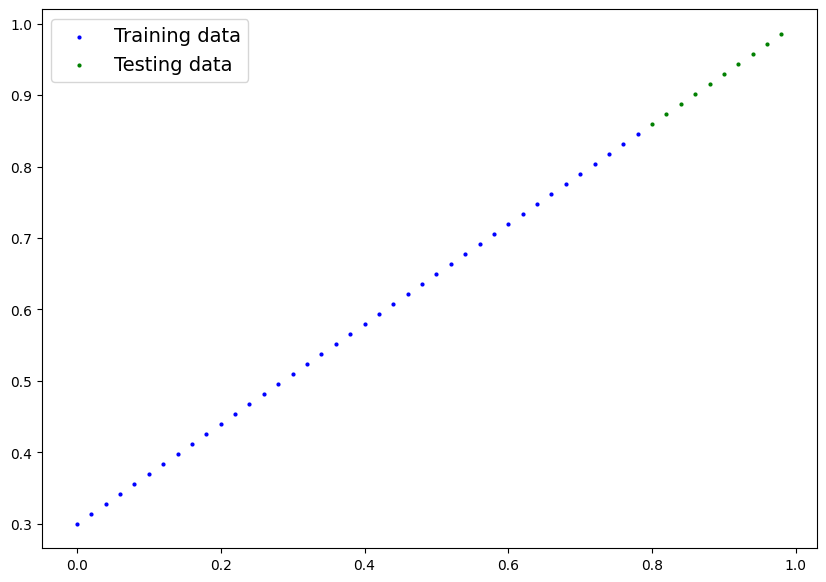

In [ ]:
plot_predictions()

## 3.Build model
>Our model will:
* Start with random value (weight and bias)
* Look at training data and adjust the random values to better represent the ideal values (weight and bias we used to create  the data)

> But how?
` By using two main algorithms: `
1. Gradient descent *(requires_grad=True)*
2. Backpropagation

In [ ]:
from torch import nn

# Create linear regression model class
class LinearRegressionModel(nn.Module): # almost everything in PyTorch inherits from nn.Module
  def __init__(self):
    super().__init__()
    self.weights = nn.Parameter(
        torch.randn(1,
            requires_grad=True,
            dtype=torch.float))
    self.bias = nn.Parameter(torch.rand(1,requires_grad=True,dtype = float))

  # Forward method to define the computation in the model
  def forward(self, x:torch.Tensor) -> torch.Tensor: # "x" is the input data
    return self.weights * x + self.bias


### 3.1 PyTorch model building essentials

* `torch.nn` - contains all of the building blocks for computational graphs
* ` torch.nn.Parameters`  - what paramateres should our model learn, often a PyTorch layer from torch.nn will set these for us
* ` torch.nn.Module ` - the base class for all neural network modules, if we subclass it we should overwrite forward()
* ` torch.optim`  - this is where the optimizers use PyTorch live (they will help with gradient descent)
* `def forward()` - all nn.Module subclasses require us to overwrite it. It defines what happens in our computation

* Resources: https://www.learnpytorch.io/pytorch_cheatsheet/

### 3.2 Checking the content of our first model

In [ ]:
# Create a random seed
torch.manual_seed(42)

# Create an instance of the model
model1 = LinearRegressionModel()

# Checkout the parameters
list(model1.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1236], dtype=torch.float64, requires_grad=True)]

In [ ]:
# List named parameters
model1.state_dict()

OrderedDict([('weights', tensor([0.3367])),
             ('bias', tensor([0.1236], dtype=torch.float64))])

### 3.3 Making predictions using 'torch.inference_mode()'
### When we pass data throgh our model, it is going to run it through the forward() method

In [ ]:
# Make prediction with model
with torch.inference_mode():
  y_preds = model1(X_test)

y_preds

tensor([[0.3929],
        [0.3997],
        [0.4064],
        [0.4131],
        [0.4199],
        [0.4266],
        [0.4333],
        [0.4401],
        [0.4468],
        [0.4535]], dtype=torch.float64)

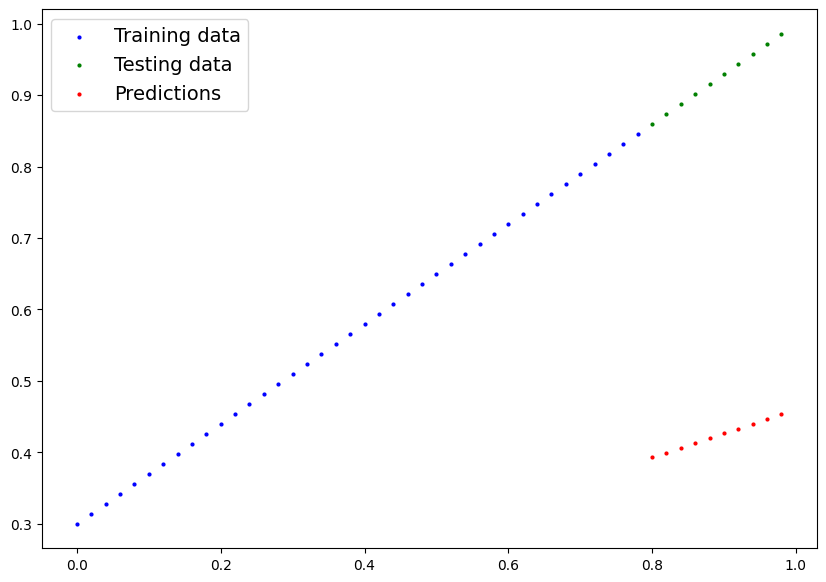

In [ ]:
plot_predictions(predictions=y_preds)

## 4.Train model
The whole idea of training model is to move from some **unknown** parameters to some **known** parameters

Or in other words from a poor representation of data to a better one

* Note: Loss function may also be called cost function or criterion in different areas. For our case, we are going to refer it as a loss function

Thing we need to train:
* **Loss function**: is a function that measures how wrong our model's predictions are to the ideal outputs **lower is better**
* **Optimizer** - takes into account the loss of a model and adjsut the model's parameters

Resources: https://www.learnpytorch.io/01_pytorch_workflow/#creating-a-loss-function-and-optimizer-in-pytorch

> And for PyTorch, we need:
* A training loop
* A testing loop



In [ ]:
# Setup a loss function
loss_fn = nn.L1Loss()

#Setup an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model1.parameters(),lr=0.01) #lr = learning rate = possibly the most important hyperparameter we can set


### 4.1 Building a training loop (and a testing loop) in PyTorch
1. Loop through the data
2. Forward pass (`forward` functions) - also called forward propagation to make predictions on data
3. Calculate the loss funciton
4. Optimizer zero grad
5. Loss backward - move backwards through the network to calculate the gradient of each of the parameters of our model
6. Optimizer step - use the optimizer to adjust our model's parameters to reduce the lose fuinction (**gradient descent**)


In [ ]:
from ast import With
# Training

# An epochis one loop through the data (hyperparameter (we set it manually))
epochs = 200

# Track diffrent values
epoch_count = []
loss_values = []
test_loss_values = []

# 1. Loop through the data
for epoch in range(epochs):
  # Set the model to training mode
  model1.train() # Train mode in PyTorch sets all parameters that require gradient to require gradients

  # 2. Forward pass
  y_pred = model1(X_train)

  # 3. Calculate the loss
  loss = loss_fn(y_pred,y_train)
  print(f"Loss:{loss}")

  # 4. Optimizer zero grad
  optimizer.zero_grad()


  # 5. Perform backpropagation on the loss with respect to the parameters of the model
  loss.backward()

  # 6. Step the optimizer
  optimizer.step() # By default optimizer changes will accumulate through the code so we should zero them above in step 4

  # TESTING
  model1.eval() #  turns off  different seeting in the model not needed for evaluating/testing (dropout/batch norm layers)

  with torch.inference_mode(): # or torch.no_grad() in old projects (it is slower)

    # 1. Do the forward pass
    test_pred = model1(X_test)

    # 2. Calculate the loss
    test_loss = loss_fn(test_pred,y_test)

# Print what is happening
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_values.append(loss)
    test_loss_values.append(test_loss)

    print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")




Loss:0.3181046841300179
Epoch: 0 | Loss: 0.3181046841300179 | Test loss: 0.4862885119004262
Loss:0.3065836892074061
Loss:0.2950626899657857
Loss:0.2835416953225707
Loss:0.27202069755942493
Loss:0.26049970106520626
Loss:0.24897870423338303
Loss:0.23745770837944863
Loss:0.2259367099760186
Loss:0.21441571477401
Loss:0.20289471868724487
Epoch: 10 | Loss: 0.20289471868724487 | Test loss: 0.3515785874409687
Loss:0.19137372033038103
Loss:0.1798527247092772
Loss:0.16833172848281375
Loss:0.1568107319420289
Loss:0.14528973442335535
Loss:0.13376873879061002
Loss:0.12224774080627518
Loss:0.11090604712189982
Loss:0.1008010269866118
Loss:0.09230161711291159
Epoch: 20 | Loss: 0.09230161711291159 | Test loss: 0.2209487388415347
Loss:0.08485216741724534
Loss:0.07870872345383831
Loss:0.07335799490858382
Loss:0.06875868888395334
Loss:0.0651028418352772
Loss:0.06198486188732426
Loss:0.05933961104766762
Loss:0.05714116913021835
Loss:0.05511795748329044
Loss:0.05343686922504778
Epoch: 30 | Loss: 0.053436869

OrderedDict([('weights', tensor([0.6947])),
             ('bias', tensor([0.2996], dtype=torch.float64))])

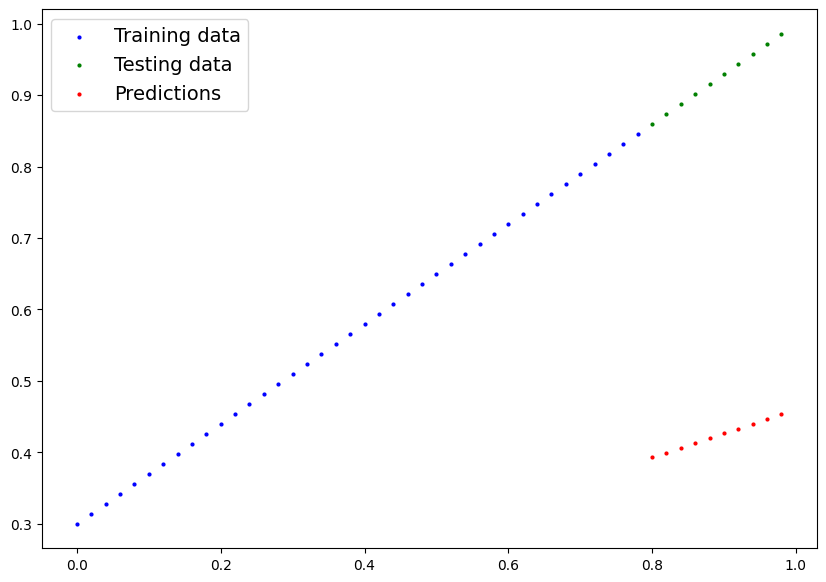

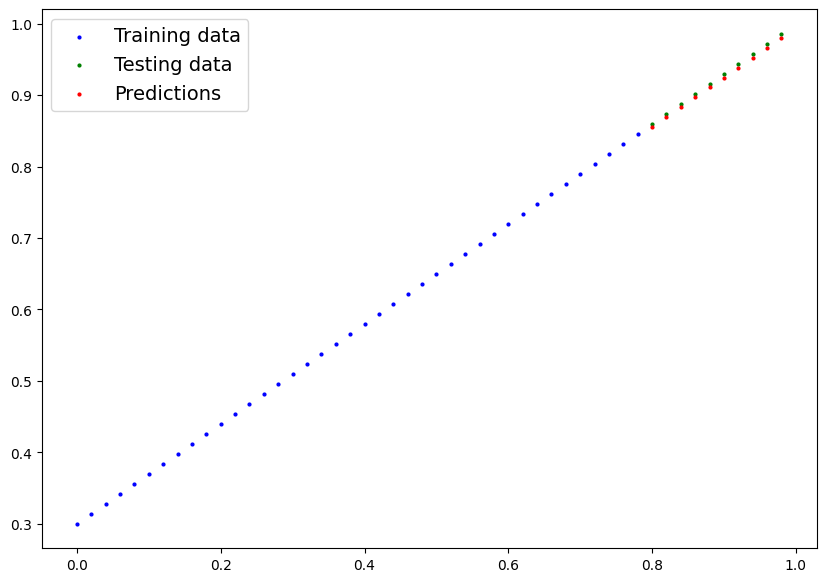

In [ ]:
# Make a new predictions and plot new and old model predictions
with torch.inference_mode():
  y_preds_new = model1(X_test)

plot_predictions(predictions=y_preds)
plot_predictions(predictions=y_preds_new)

# Print out model state
with torch.inference_mode():
  model1.state_dict()
model1.state_dict()

## 5.Saving and loading models

### 5.1 Saving a model in PyTorch

There are three main methods we should know about:
1. 'torch.save' - save our PyTorch project in Python's pickle format
2. 'torch.load' - allows to load a saved PyTorch project
3. 'torch.nn.Module.load_state_dict()' - allows to load a models saved state dictionary
> **Resources: https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html**

In [ ]:
# Saving our PyTorch module
from pathlib import Path

# 1.Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True )

# 2.Create model save path
MODEL_NAME = "01_pytroch_workflow_model_1.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3.Save the model.state_dict (RECOMMENDED)
print(f"Saving model to {MODEL_SAVE_PATH}")
torch.save(obj=model1.state_dict(),f=MODEL_SAVE_PATH)


Saving model to models/01_pytroch_workflow_model_1.pth


### 5.2 Loading a PyTorch model
*Since we saved out 'state_dict()' rather than entire model we create a new instance of our model and load the saved 'state_dict()' into that*

In [ ]:
# To load  we have to instanciate a new instance of our class
loaded_model1 = LinearRegressionModel()

# Load the saved state_dict of model1
loaded_model1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model1.state_dict()

# Make a predistctions to make sure its our loaded model
loaded_model1.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model1(X_test)
loaded_model_preds

# Compare loaded model preds with original ones
y_preds == loaded_model_preds

tensor([[False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False],
        [False]])

## 6.Putting it all together

*Let's go back through the steps above to see it all in one place*

### 6.1 Data

In [ ]:
# Import PyTorch and matplotlib
import torch
from torch import nn
import matplotlib.pyplot as plt

# Check PyTorch version
torch.__version__

'2.10.0+cu128'

In [ ]:
#Create device-agnostic code (if we have acces to GPU, our code will use it for faster **performance**)
device ="cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

!nvidia-smi

Device: cuda
Wed Apr  8 12:38:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+----------------------------------

In [ ]:
# Create Data
# Create some data with linear regression formula: y = wight*X + bias
weight = 0.7
bias = 0.3

# Create range varaibles
start = 0
end = 1
step = 0.02

# Create X and y(featureas and labels)
X = torch.arange(start,end,step).unsqueeze(dim=1) # Without unsqueeze errors will pop
y = weight * X + bias

X[:10],y[:10]


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [ ]:
# Split Data
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]
len(X_train), len(X_test),len(y_train), len(y_test)

(40, 10, 40, 10)

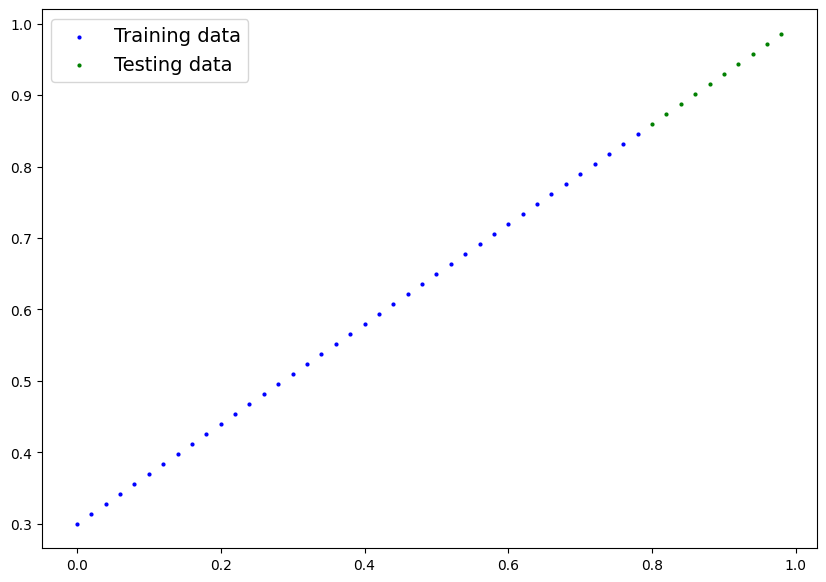

In [ ]:
# Plot the data
plot_predictions(X_train,y_train,X_test,y_test)

### 6.2 Building a PyTorch model

In [ ]:
# Create a linear model by subclassing nn.Module
class LinearRegressionModelv2(nn.Module):
  def __init__(self):
    super().__init__()
    # Use nn.Linear() for creating the model parameters AKA lienar transform, dense lear, fully-connected layer etc..
    self.linear_layer = nn.Linear(in_features=1,out_features=1)

  def forward(self,x) -> torch.Tensor:
    return self.linear_layer(x)

# Set the manual seed
torch.manual_seed(42)
model2 = LinearRegressionModelv2()
model2, model2.state_dict()


(LinearRegressionModelv2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
# Check the model current device
next(model2.parameters()).device

device(type='cpu')

In [ ]:
# Set the model to use the target device
model2.to(device)
next(model2.parameters()).device

device(type='cuda', index=0)

### 6.3 Training
1. Loss function
2. Optimizer
3. Training loop
4. Testing loop

In [ ]:
# Setup the loss function
loss_fn = nn.L1Loss() # same as MAE

# Setup our optimizer
optimizer =  torch.optim.SGD(params=model2.parameters(),lr=0.01)

# Train loop
torch.manual_seed(42)

epochs = 200

for epoch in range(epochs):
  model2.train()

  # 1. Forward pass
  y_pred = model2(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)

  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Perform backpropagation
  loss.backward()

  #5 Optimizer step
  optimizer.step()

  ## Testing
  model2.eval()
  with torch.inference_mode():
    test_pred = model2(X_test)
    test_Loss = loss_fn(test_pred,y_test)

    # Print what is happening
    if epoch % 10 == 0:
      print(f"Epoch : {epoch} | Loss: {loss} | Test loss: {test_Loss}")

Epoch : 0 | Loss: 0.5551779866218567 | Test loss: 0.5739762187004089
Epoch : 10 | Loss: 0.4399680495262146 | Test loss: 0.4392663538455963
Epoch : 20 | Loss: 0.3247582018375397 | Test loss: 0.30455657839775085
Epoch : 30 | Loss: 0.20954827964305878 | Test loss: 0.16984674334526062
Epoch : 40 | Loss: 0.09433844685554504 | Test loss: 0.03513689711689949
Epoch : 50 | Loss: 0.023886386305093765 | Test loss: 0.04784906655550003
Epoch : 60 | Loss: 0.0199567973613739 | Test loss: 0.04580312222242355
Epoch : 70 | Loss: 0.016517987474799156 | Test loss: 0.0375305712223053
Epoch : 80 | Loss: 0.013089170679450035 | Test loss: 0.029944902285933495
Epoch : 90 | Loss: 0.009653178043663502 | Test loss: 0.02167237363755703
Epoch : 100 | Loss: 0.006215679459273815 | Test loss: 0.014086711220443249
Epoch : 110 | Loss: 0.002787243574857712 | Test loss: 0.005814164876937866
Epoch : 120 | Loss: 0.0012645035749301314 | Test loss: 0.013801807537674904
Epoch : 130 | Loss: 0.0012645035749301314 | Test loss: 0.

In [ ]:
weight, bias

(0.7, 0.3)

In [ ]:
model2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

### 6.4 Making predictions

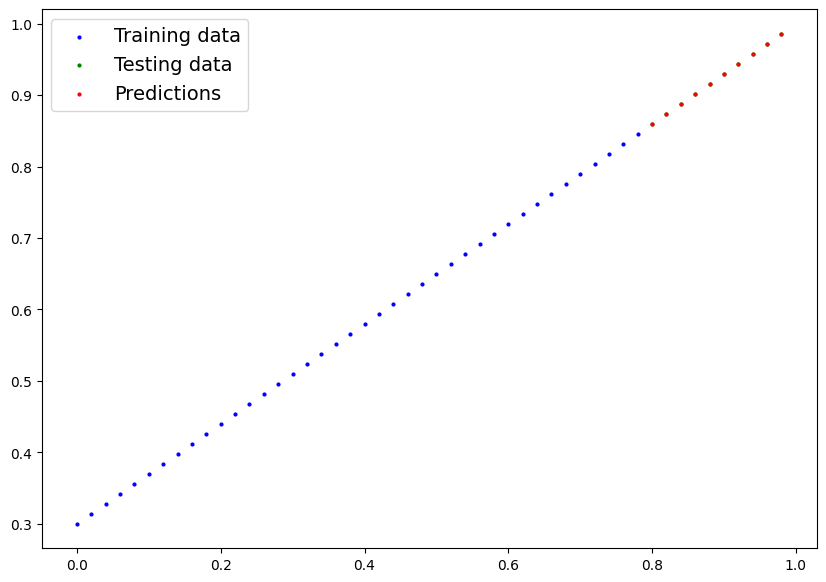

In [ ]:
# Turn model into evaluation mode
model2.eval()

# Make predicitions
with torch.inference_mode():
  y_preds = model2(X_test)
y_preds

# Plot the predictions
plot_predictions(predictions=y_preds)

### 6.5 Saving and loading the model


In [ ]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "01_pytorch_workflow_model_2.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

print(f"Saving model {MODEL_NAME} to {MODEL_PATH}")
torch.save(obj=model2.state_dict(),f=MODEL_SAVE_PATH)


Saving model 01_pytorch_workflow_model_2.pth to models


### 6.6 Load the model

In [ ]:
loaded_model2 = LinearRegressionModelv2()
loaded_model2.load_state_dict(torch.load(MODEL_SAVE_PATH))

next(loaded_model2.parameters()).device
loaded_model2.state_dict()

# Evaluate loaded model

loaded_model2.eval()
with torch.inference_mode():
  loaded_model2_preds = loaded_model2(X_test)
y_preds == loaded_model2_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])